# Step 5 - Loss Ratio & Profitability Analysis

Notebook ini menjawab pertanyaan: **segmen mana yang paling menguntungkan dan paling merugikan?**

Cakupan analisis:
- Gross Loss Ratio = Gross Incurred Claim / GWP
- Net Loss Ratio = Net Incurred Claim / Net Premium
- Ranking loss ratio per segmen
- Perbandingan Gross vs Net Loss Ratio
- Analisis profitability dengan large claim vs tanpa large claim
- Analisis tren loss ratio per underwriting year

Asumsi yang digunakan:
- Data premium diagregasi ke level `POLICY_NO` karena satu policy bisa muncul beberapa kali.
- Data claim juga diagregasi ke level `POLICY_NO` sebelum digabungkan.
- Gross incurred claim = `GRS_ST_IDR + GRS_OS_IDR`.
- Net incurred claim = gross incurred claim - `(RI_ST_IDR + RI_OS_IDR)`.
- Net premium = `GWP_IDR - RWP_IDR`.
- Large claim didefinisikan sebagai claim policy-level di atas quantile tertentu, dan threshold-nya bisa diubah.


In [3]:
import io
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.display import display

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
sns.set_theme(style='whitegrid')

# Config yang mudah diubah
USE_COLAB_UPLOAD = True
LOCAL_FILE_PATH = '/content/Study Case for Univ Airlangga 2026 _Actuarial AXA (Sent 2026.05.26) (1).xlsx'
SEGMENT_COLS = ['COB', 'BRANCH_', 'CHANNEL_', 'PRODUCT_NAME']
MIN_GWP_BY_SEGMENT = 1_000_000_000
TOP_N = 10
LARGE_CLAIM_QUANTILE = 0.95
FOCUS_SEGMENT_FOR_TREND = 'COB'

if USE_COLAB_UPLOAD:
    from google.colab import files
    uploaded = files.upload()
    file_path = next(iter(uploaded.keys()))
else:
    file_path = LOCAL_FILE_PATH

print(f'File yang dipakai: {file_path}')


Saving Study Case for Univ Airlangga 2026 _Actuarial AXA (Sent 2026.05.26) (1).xlsx to Study Case for Univ Airlangga 2026 _Actuarial AXA (Sent 2026.05.26) (1) (1).xlsx
File yang dipakai: Study Case for Univ Airlangga 2026 _Actuarial AXA (Sent 2026.05.26) (1) (1).xlsx


In [4]:
premium_cols = [
    'COB', 'BRANCH_', 'CHANNEL_', 'PRODUCT_NAME', 'POLICY_NO',
    'DT_INC', 'DT_END', 'GWP_IDR', 'RWP_IDR', 'GWC_IDR', 'RWC_IDR', 'SUM_INSURED'
]
claim_cols = [
    'COB', 'BRANCH_', 'CHANNEL_', 'POLICY_NO', 'CLM_REF', 'DT_CLM',
    'GRS_ST_IDR', 'RI_ST_IDR', 'GRS_OS_IDR', 'RI_OS_IDR'
]

premium = pd.read_excel(file_path, sheet_name='Raw Premium', usecols=premium_cols)
claim = pd.read_excel(file_path, sheet_name='Raw Claim', usecols=claim_cols)

date_cols_premium = ['DT_INC', 'DT_END']
date_cols_claim = ['DT_CLM']
num_cols_premium = ['GWP_IDR', 'RWP_IDR', 'GWC_IDR', 'RWC_IDR', 'SUM_INSURED']
num_cols_claim = ['GRS_ST_IDR', 'RI_ST_IDR', 'GRS_OS_IDR', 'RI_OS_IDR']

for col in date_cols_premium:
    premium[col] = pd.to_datetime(premium[col], errors='coerce')
for col in date_cols_claim:
    claim[col] = pd.to_datetime(claim[col], errors='coerce')
for col in num_cols_premium:
    premium[col] = pd.to_numeric(premium[col], errors='coerce').fillna(0)
for col in num_cols_claim:
    claim[col] = pd.to_numeric(claim[col], errors='coerce').fillna(0)

print('Premium shape :', premium.shape)
print('Claim shape   :', claim.shape)
display(premium.head())
display(claim.head())


Premium shape : (390124, 12)
Claim shape   : (20087, 10)


,COB,BRANCH_,CHANNEL_,PRODUCT_NAME,POLICY_NO,DT_INC,DT_END,GWP_IDR,RWP_IDR,GWC_IDR,RWC_IDR,SUM_INSURED
0,COB 1,BRANCH J,CHANNEL D,PRODUCT0803,YY_00001100803012100001,2021-01-01,2021-07-01,"37,514.11",0.00,0.00,0.00,"42,500,000.00"
1,COB 1,BRANCH J,CHANNEL D,PRODUCT0803,YY_00001100803012100003,2021-01-01,2021-07-01,"443,738.96",0.00,0.00,0.00,"502,715,000.00"
2,COB 1,BRANCH J,CHANNEL D,PRODUCT0803,YY_00001020803022100007,2021-01-01,2021-08-01,"452,315.07",0.00,"45,231.51",0.00,"437,500,000.00"
3,COB 1,BRANCH J,CHANNEL D,PRODUCT0803,YY_00001020803122000006,2021-01-01,2021-08-01,"96,924.66",0.00,"9,692.47",0.00,"93,750,000.00"
4,COB 1,BRANCH J,CHANNEL D,PRODUCT0803,YY_00001020803122000007,2021-01-01,2021-08-01,"2,756,090.75",0.00,"275,609.08",0.00,"238,750,000.00"


,COB,BRANCH_,CHANNEL_,POLICY_NO,CLM_REF,DT_CLM,GRS_ST_IDR,RI_ST_IDR,GRS_OS_IDR,RI_OS_IDR
0,COB 1,BRANCH J,CHANNEL A,YY_00001110802022100001,XX_-110802042200001,2022-03-31,"9,000,000.00",0.00,0.00,0.00
1,COB 1,BRANCH J,CHANNEL A,YY_00001110802022100001,XX_-110802072200001,2022-07-05,"41,198,727.60",0.00,0.00,0.00
2,COB 1,BRANCH D,CHANNEL E,YY_00001050808072100002,XX_-050808122100013,2021-12-03,"517,752,648.00","457,057,854.92",0.00,0.00
3,COB 1,BRANCH D,CHANNEL E,YY_00001050808022100001,XX_-050808122100001,2021-07-19,"36,371,730.60","34,895,511.95",0.00,0.00
4,COB 1,BRANCH D,CHANNEL E,YY_00001050808022100001,XX_-050808012200001,2021-07-20,"1,188,597,879.90","1,140,356,283.24",0.00,0.00


In [5]:
# Agregasi ke level policy agar tidak double count saat join premium dan claim.
premium_policy = (
    premium.sort_values(['POLICY_NO', 'DT_INC'])
    .groupby('POLICY_NO', as_index=False)
    .agg({
        'COB': 'first',
        'BRANCH_': 'first',
        'CHANNEL_': 'first',
        'PRODUCT_NAME': 'first',
        'DT_INC': 'min',
        'DT_END': 'max',
        'GWP_IDR': 'sum',
        'RWP_IDR': 'sum',
        'GWC_IDR': 'sum',
        'RWC_IDR': 'sum',
        'SUM_INSURED': 'max'
    })
)

claim_policy = (
    claim.groupby('POLICY_NO', as_index=False)
    .agg({
        'CLM_REF': 'nunique',
        'DT_CLM': 'min',
        'GRS_ST_IDR': 'sum',
        'RI_ST_IDR': 'sum',
        'GRS_OS_IDR': 'sum',
        'RI_OS_IDR': 'sum'
    })
    .rename(columns={'CLM_REF': 'claim_count'})
)

df = premium_policy.merge(claim_policy, on='POLICY_NO', how='left')

claim_fill_cols = ['claim_count', 'GRS_ST_IDR', 'RI_ST_IDR', 'GRS_OS_IDR', 'RI_OS_IDR']
df[claim_fill_cols] = df[claim_fill_cols].fillna(0)

df['uw_year'] = df['DT_INC'].dt.year
df['net_premium'] = df['GWP_IDR'] - df['RWP_IDR']
df['gross_incurred_claim'] = df['GRS_ST_IDR'] + df['GRS_OS_IDR']
df['ri_recoveries'] = df['RI_ST_IDR'] + df['RI_OS_IDR']
df['net_incurred_claim'] = df['gross_incurred_claim'] - df['ri_recoveries']
df['has_claim'] = df['gross_incurred_claim'] > 0

positive_claims = df.loc[df['gross_incurred_claim'] > 0, 'gross_incurred_claim']
large_claim_threshold = positive_claims.quantile(LARGE_CLAIM_QUANTILE)
df['is_large_claim'] = df['gross_incurred_claim'] >= large_claim_threshold

overall = pd.DataFrame({
    'metric': [
        'policy_count', 'claim_policy_count', 'gross_written_premium',
        'net_premium', 'gross_incurred_claim', 'net_incurred_claim',
        'large_claim_threshold'
    ],
    'value': [
        len(df),
        int(df['has_claim'].sum()),
        df['GWP_IDR'].sum(),
        df['net_premium'].sum(),
        df['gross_incurred_claim'].sum(),
        df['net_incurred_claim'].sum(),
        large_claim_threshold
    ]
})

display(overall)
display(df.head())


,metric,value
0,policy_count,"156,301.00"
1,claim_policy_count,"8,585.00"
2,gross_written_premium,"2,510,719,474,050.44"
3,net_premium,"1,964,121,257,568.66"
4,gross_incurred_claim,"1,238,881,565,028.47"
5,net_incurred_claim,"1,149,753,089,769.06"
6,large_claim_threshold,"153,078,629.76"


,POLICY_NO,COB,BRANCH_,CHANNEL_,PRODUCT_NAME,DT_INC,DT_END,GWP_IDR,RWP_IDR,GWC_IDR,RWC_IDR,SUM_INSURED,claim_count,DT_CLM,GRS_ST_IDR,RI_ST_IDR,GRS_OS_IDR,RI_OS_IDR,uw_year,net_premium,gross_incurred_claim,ri_recoveries,net_incurred_claim,has_claim,is_large_claim
0,YY_000000AGI-1-00258366,COB 2,BRANCH K,CHANNEL B,PRODUCT13AG,2023-03-01,2023-04-01,"72,482,500.00","7,686.36","21,744,750.00","1,867.57","450,000,000.00",0.00,NaT,0.00,0.00,0.00,0.00,2023,"72,474,813.64",0.00,0.00,0.00,False,False
1,YY_000000AGI-1-00260948,COB 2,BRANCH K,CHANNEL B,PRODUCT13AG,2023-01-07,2023-02-06,"30,607,500.00","3,267.45","9,182,250.00",796.59,"900,000,000.00",0.00,NaT,0.00,0.00,0.00,0.00,2023,"30,604,232.55",0.00,0.00,0.00,False,False
2,YY_000000AGI-1-00261491,COB 2,BRANCH K,CHANNEL B,PRODUCT13AG,2023-08-18,2023-09-18,"33,390,000.00","3,267.45","10,017,000.00",796.59,"900,000,000.00",0.00,NaT,0.00,0.00,0.00,0.00,2023,"33,386,732.55",0.00,0.00,0.00,False,False
3,YY_000000AGI-1-00262632,COB 2,BRANCH K,CHANNEL B,PRODUCT13AG,2023-02-03,2023-03-03,"16,843,750.00","1,763.67","5,053,125.00",431.48,"450,000,000.00",0.00,NaT,0.00,0.00,0.00,0.00,2023,"16,841,986.33",0.00,0.00,0.00,False,False
4,YY_000000AGI-1-00262638,COB 2,BRANCH K,CHANNEL B,PRODUCT13AG,2023-03-03,2023-04-03,"38,707,500.00","4,001.02","11,612,250.00",978.85,"1,350,000,000.00",0.00,NaT,0.00,0.00,0.00,0.00,2023,"38,703,498.98",0.00,0.00,0.00,False,False


In [6]:
def summarize_loss_ratio(data, group_col, min_gwp=0):
    summary = (
        data.groupby(group_col, dropna=False)
        .agg(
            policy_count=('POLICY_NO', 'nunique'),
            claim_policy_count=('has_claim', 'sum'),
            large_claim_policy_count=('is_large_claim', 'sum'),
            gwp=('GWP_IDR', 'sum'),
            rwp=('RWP_IDR', 'sum'),
            net_premium=('net_premium', 'sum'),
            gross_incurred_claim=('gross_incurred_claim', 'sum'),
            net_incurred_claim=('net_incurred_claim', 'sum')
        )
        .reset_index()
    )
    summary = summary[summary['gwp'] >= min_gwp].copy()
    summary['gross_loss_ratio_pct'] = np.where(
        summary['gwp'] > 0,
        100 * summary['gross_incurred_claim'] / summary['gwp'],
        np.nan
    )
    summary['net_loss_ratio_pct'] = np.where(
        summary['net_premium'] > 0,
        100 * summary['net_incurred_claim'] / summary['net_premium'],
        np.nan
    )
    summary['reinsurance_benefit_pct_point'] = (
        summary['gross_loss_ratio_pct'] - summary['net_loss_ratio_pct']
    )
    summary['profitability_flag'] = np.where(
        summary['net_loss_ratio_pct'] > 100,
        'Loss-making',
        'Profitable/acceptable'
    )
    return summary.sort_values('net_loss_ratio_pct', ascending=True).reset_index(drop=True)


def portfolio_metrics(data, label):
    gross_lr = 100 * data['gross_incurred_claim'].sum() / data['GWP_IDR'].sum()
    net_lr = 100 * data['net_incurred_claim'].sum() / data['net_premium'].sum()
    return pd.DataFrame({
        'scenario': [label],
        'policy_count': [data['POLICY_NO'].nunique()],
        'claim_policy_count': [int(data['has_claim'].sum())],
        'gwp': [data['GWP_IDR'].sum()],
        'net_premium': [data['net_premium'].sum()],
        'gross_incurred_claim': [data['gross_incurred_claim'].sum()],
        'net_incurred_claim': [data['net_incurred_claim'].sum()],
        'gross_loss_ratio_pct': [gross_lr],
        'net_loss_ratio_pct': [net_lr]
    })


segment_summaries = {
    col: summarize_loss_ratio(df, col, min_gwp=MIN_GWP_BY_SEGMENT)
    for col in SEGMENT_COLS
}

for col, summary in segment_summaries.items():
    print(f'=== Ranking segment by {col} (best net loss ratio) ===')
    display(summary.head(TOP_N))
    print(f'=== Ranking segment by {col} (worst net loss ratio) ===')
    display(summary.sort_values('net_loss_ratio_pct', ascending=False).head(TOP_N))


=== Ranking segment by COB (best net loss ratio) ===


,COB,policy_count,claim_policy_count,large_claim_policy_count,gwp,rwp,net_premium,gross_incurred_claim,net_incurred_claim,gross_loss_ratio_pct,net_loss_ratio_pct,reinsurance_benefit_pct_point,profitability_flag
0,COB 3,835,36,2,"57,467,926,067.73","42,919,774,251.80","14,548,151,815.93","1,280,414,194.54","877,956,469.18",2.23,6.03,-3.81,Profitable/acceptable
1,COB 10,52085,330,6,"64,892,499,838.20",0.00,"64,892,499,838.20","5,870,562,105.60","5,870,562,105.60",9.05,9.05,0.00,Profitable/acceptable
2,COB 8,2382,50,4,"251,534,301,544.45","44,825,850.00","251,489,475,694.45","37,829,764,117.97","37,829,764,117.97",15.04,15.04,-0.00,Profitable/acceptable
3,COB 9,46754,704,110,"762,410,875,051.46","295,418,868,386.00","466,992,006,665.47","130,691,192,885.20","87,922,835,666.55",17.14,18.83,-1.69,Profitable/acceptable
4,COB 1,4983,97,24,"119,618,908,447.19","69,935,087,727.82","49,683,820,719.38","26,166,689,951.10","12,783,916,170.13",21.88,25.73,-3.86,Profitable/acceptable
5,COB 2,21,3,2,"20,945,635,570.40","51,802.34","20,945,583,768.06","5,434,200,000.00","5,434,200,000.00",25.94,25.94,-0.00,Profitable/acceptable
6,COB 5,909,62,35,"151,000,896,289.24","76,311,390,292.49","74,689,505,996.75","58,025,722,142.83","37,047,819,857.04",38.43,49.60,-11.18,Profitable/acceptable
7,COB 7,41763,6986,109,"342,980,363,837.09","283,482,868.75","342,696,880,968.34","298,159,145,749.09","298,129,456,009.09",86.93,87.00,-0.06,Profitable/acceptable
8,COB 6,4876,109,12,"420,660,523,861.31","5,476,913,501.38","415,183,610,359.93","384,069,692,453.56","383,638,600,841.99",91.30,92.40,-1.10,Profitable/acceptable
9,COB 4,1693,208,126,"319,207,543,543.36","56,207,821,801.20","262,999,721,742.16","291,354,181,428.57","280,217,978,531.52",91.27,106.55,-15.27,Loss-making


=== Ranking segment by COB (worst net loss ratio) ===


,COB,policy_count,claim_policy_count,large_claim_policy_count,gwp,rwp,net_premium,gross_incurred_claim,net_incurred_claim,gross_loss_ratio_pct,net_loss_ratio_pct,reinsurance_benefit_pct_point,profitability_flag
9,COB 4,1693,208,126,"319,207,543,543.36","56,207,821,801.20","262,999,721,742.16","291,354,181,428.57","280,217,978,531.52",91.27,106.55,-15.27,Loss-making
8,COB 6,4876,109,12,"420,660,523,861.31","5,476,913,501.38","415,183,610,359.93","384,069,692,453.56","383,638,600,841.99",91.30,92.40,-1.10,Profitable/acceptable
7,COB 7,41763,6986,109,"342,980,363,837.09","283,482,868.75","342,696,880,968.34","298,159,145,749.09","298,129,456,009.09",86.93,87.00,-0.06,Profitable/acceptable
6,COB 5,909,62,35,"151,000,896,289.24","76,311,390,292.49","74,689,505,996.75","58,025,722,142.83","37,047,819,857.04",38.43,49.60,-11.18,Profitable/acceptable
5,COB 2,21,3,2,"20,945,635,570.40","51,802.34","20,945,583,768.06","5,434,200,000.00","5,434,200,000.00",25.94,25.94,-0.00,Profitable/acceptable
4,COB 1,4983,97,24,"119,618,908,447.19","69,935,087,727.82","49,683,820,719.38","26,166,689,951.10","12,783,916,170.13",21.88,25.73,-3.86,Profitable/acceptable
3,COB 9,46754,704,110,"762,410,875,051.46","295,418,868,386.00","466,992,006,665.47","130,691,192,885.20","87,922,835,666.55",17.14,18.83,-1.69,Profitable/acceptable
2,COB 8,2382,50,4,"251,534,301,544.45","44,825,850.00","251,489,475,694.45","37,829,764,117.97","37,829,764,117.97",15.04,15.04,-0.00,Profitable/acceptable
1,COB 10,52085,330,6,"64,892,499,838.20",0.00,"64,892,499,838.20","5,870,562,105.60","5,870,562,105.60",9.05,9.05,0.00,Profitable/acceptable
0,COB 3,835,36,2,"57,467,926,067.73","42,919,774,251.80","14,548,151,815.93","1,280,414,194.54","877,956,469.18",2.23,6.03,-3.81,Profitable/acceptable


=== Ranking segment by BRANCH_ (best net loss ratio) ===


...

,CHANNEL_,policy_count,claim_policy_count,large_claim_policy_count,gwp,rwp,net_premium,gross_incurred_claim,net_incurred_claim,gross_loss_ratio_pct,net_loss_ratio_pct,reinsurance_benefit_pct_point,profitability_flag
4,CHANNEL B,37067,583,18,"487,719,216,106.31","4,569,470,788.65","483,149,745,317.65","561,390,367,641.47","561,206,338,601.56",115.11,116.16,-1.05,Loss-making
3,CHANNEL C,9302,1038,197,"701,559,305,940.26","331,410,355,569.25","370,148,950,371.02","382,878,095,550.27","317,904,905,346.55",54.58,85.89,-31.31,Profitable/acceptable
2,CHANNEL E,6453,856,115,"327,136,065,737.91","135,647,122,916.31","191,488,942,821.60","89,295,548,636.50","75,773,511,304.23",27.30,39.57,-12.27,Profitable/acceptable
1,CHANNEL A,42250,1807,53,"236,633,781,240.56","29,438,025,375.29","207,195,755,865.28","74,582,430,385.17","69,516,102,780.56",31.52,33.55,-2.03,Profitable/acceptable
0,CHANNEL D,61229,4301,47,"757,671,105,025.40","45,533,241,832.28","712,137,863,193.12","130,735,122,815.06","125,352,231,736.17",17.25,17.60,-0.35,Profitable/acceptable


=== Ranking segment by PRODUCT_NAME (best net loss ratio) ===


,PRODUCT_NAME,policy_count,claim_policy_count,large_claim_policy_count,gwp,rwp,net_premium,gross_incurred_claim,net_incurred_claim,gross_loss_ratio_pct,net_loss_ratio_pct,reinsurance_benefit_pct_point,profitability_flag
0,PRODUCT0106,94,0,0,"1,008,103,470.85","364,623,067.67","643,480,403.18",0.00,0.00,0.00,0.00,0.00,Profitable/acceptable
1,PRODUCT0111,141,1,0,"2,556,288,144.83","2,556,288,144.83",0.00,"30,702,252.60",0.00,1.20,0.00,1.20,Profitable/acceptable
2,PRODUCT0123,5057,0,0,"64,149,698,849.48","1,603,696,962.45","62,546,001,887.03",0.00,0.00,0.00,0.00,0.00,Profitable/acceptable
3,PRODUCT0135,1048,0,0,"3,248,930,503.91","1,170,117,553.62","2,078,812,950.29",0.00,0.00,0.00,0.00,0.00,Profitable/acceptable
4,PRODUCT0225,1,0,0,"6,653,125,329.68",0.00,"6,653,125,329.68",0.00,0.00,0.00,0.00,0.00,Profitable/acceptable
5,PRODUCT0451,18,0,0,"1,508,165,396.59","784,246,006.23","723,919,390.36",0.00,0.00,0.00,0.00,0.00,Profitable/acceptable
6,PRODUCT0913,46,0,0,"8,086,109,181.25","6,499,996,689.80","1,586,112,491.45",0.00,0.00,0.00,0.00,0.00,Profitable/acceptable
7,PRODUCT0812,42,0,0,"1,232,415,878.81","545,177,726.83","687,238,151.99",0.00,0.00,0.00,0.00,0.00,Profitable/acceptable
8,PRODUCT1201,1786,0,0,"4,782,690,750.18","40,440,712.50","4,742,250,037.68",0.00,0.00,0.00,0.00,0.00,Profitable/acceptable
9,PRODUCT1024,11,0,0,"3,010,247,759.70",0.00,"3,010,247,759.70",0.00,0.00,0.00,0.00,0.00,Profitable/acceptable


=== Ranking segment by PRODUCT_NAME (worst net loss ratio) ===


,PRODUCT_NAME,policy_count,claim_policy_count,large_claim_policy_count,gwp,rwp,net_premium,gross_incurred_claim,net_incurred_claim,gross_loss_ratio_pct,net_loss_ratio_pct,reinsurance_benefit_pct_point,profitability_flag
55,PRODUCT1217,2356,57,1,"1,738,130,096.12",0.00,"1,738,130,096.12","366,456,399,711.30","366,456,399,711.30","21,083.37","21,083.37",0.00,Loss-making
54,PRODUCT0221,37522,6156,73,"223,116,509,029.14","157,832,556.25","222,958,676,472.89","268,859,246,040.59","268,859,246,040.59",120.50,120.59,-0.09,Loss-making
53,PRODUCT1212,31,2,2,"1,716,722,465.85",0.00,"1,716,722,465.85","2,063,184,349.95","2,063,184,349.95",120.18,120.18,0.00,Loss-making
52,PRODUCT0311,681,192,120,"293,808,830,710.02","44,068,009,077.96","249,740,821,632.06","288,026,668,096.73","278,806,413,828.43",98.03,111.64,-13.61,Loss-making
51,PRODUCT0803,2151,64,10,"11,378,625,646.72","5,844,451,350.38","5,534,174,296.34","11,379,429,112.44","5,433,465,669.46",100.01,98.18,1.83,Profitable/acceptable
50,PRODUCT0401,891,62,35,"149,492,730,892.65","75,527,144,286.27","73,965,586,606.39","58,025,722,142.83","37,047,819,857.04",38.82,50.09,-11.27,Profitable/acceptable
49,PRODUCT0121,7026,10,5,"16,755,635,577.77","3,370,034,377.15","13,385,601,200.62","6,697,718,926.93","6,217,901,832.86",39.97,46.45,-6.48,Profitable/acceptable
48,PRODUCT0109,7068,421,50,"143,192,481,419.65","59,474,283,343.31","83,718,198,076.34","58,961,024,180.80","36,483,485,549.60",41.18,43.58,-2.40,Profitable/acceptable
47,PRODUCT0110,1545,135,27,"132,827,204,958.30","93,842,169,194.05","38,985,035,764.26","28,968,032,741.31","16,767,232,004.99",21.81,43.01,-21.20,Profitable/acceptable
46,PRODUCT0201,3178,744,29,"57,383,262,167.93","125,650,312.50","57,257,611,855.43","24,198,529,609.40","24,168,839,869.40",42.17,42.21,-0.04,Profitable/acceptable


,COB,policy_count,claim_policy_count,large_claim_policy_count,gwp,rwp,net_premium,gross_incurred_claim,net_incurred_claim,gross_loss_ratio_pct,net_loss_ratio_pct,reinsurance_benefit_pct_point,profitability_flag
0,COB 3,835,36,2,"57,467,926,067.73","42,919,774,251.80","14,548,151,815.93","1,280,414,194.54","877,956,469.18",2.23,6.03,-3.81,Profitable/acceptable
1,COB 10,52085,330,6,"64,892,499,838.20",0.00,"64,892,499,838.20","5,870,562,105.60","5,870,562,105.60",9.05,9.05,0.00,Profitable/acceptable
2,COB 8,2382,50,4,"251,534,301,544.45","44,825,850.00","251,489,475,694.45","37,829,764,117.97","37,829,764,117.97",15.04,15.04,-0.00,Profitable/acceptable
3,COB 9,46754,704,110,"762,410,875,051.46","295,418,868,386.00","466,992,006,665.47","130,691,192,885.20","87,922,835,666.55",17.14,18.83,-1.69,Profitable/acceptable
4,COB 1,4983,97,24,"119,618,908,447.19","69,935,087,727.82","49,683,820,719.38","26,166,689,951.10","12,783,916,170.13",21.88,25.73,-3.86,Profitable/acceptable
5,COB 2,21,3,2,"20,945,635,570.40","51,802.34","20,945,583,768.06","5,434,200,000.00","5,434,200,000.00",25.94,25.94,-0.00,Profitable/acceptable
6,COB 5,909,62,35,"151,000,896,289.24","76,311,390,292.49","74,689,505,996.75","58,025,722,142.83","37,047,819,857.04",38.43,49.60,-11.18,Profitable/acceptable
7,COB 7,41763,6986,109,"342,980,363,837.09","283,482,868.75","342,696,880,968.34","298,159,145,749.09","298,129,456,009.09",86.93,87.00,-0.06,Profitable/acceptable
8,COB 6,4876,109,12,"420,660,523,861.31","5,476,913,501.38","415,183,610,359.93","384,069,692,453.56","383,638,600,841.99",91.30,92.40,-1.10,Profitable/acceptable
9,COB 4,1693,208,126,"319,207,543,543.36","56,207,821,801.20","262,999,721,742.16","291,354,181,428.57","280,217,978,531.52",91.27,106.55,-15.27,Loss-making


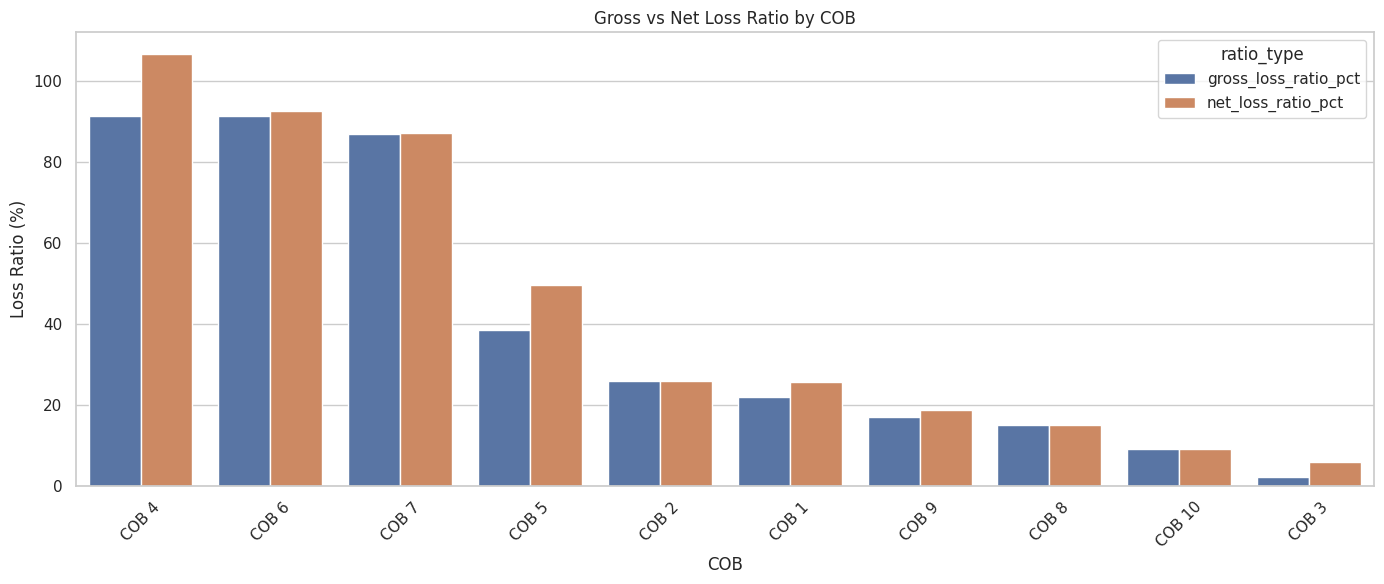

Segmen paling menguntungkan pada dimensi fokus:


,COB,gross_loss_ratio_pct,net_loss_ratio_pct,profitability_flag
0,COB 3,2.23,6.03,Profitable/acceptable


Segmen paling merugikan pada dimensi fokus:


,COB,gross_loss_ratio_pct,net_loss_ratio_pct,profitability_flag
9,COB 4,91.27,106.55,Loss-making


In [7]:
focus_summary = summarize_loss_ratio(df, FOCUS_SEGMENT_FOR_TREND, min_gwp=MIN_GWP_BY_SEGMENT)
focus_chart = focus_summary.sort_values('net_loss_ratio_pct', ascending=False).head(TOP_N).copy()

display(focus_summary)

plt.figure(figsize=(14, 6))
chart_data = focus_chart.melt(
    id_vars=[FOCUS_SEGMENT_FOR_TREND],
    value_vars=['gross_loss_ratio_pct', 'net_loss_ratio_pct'],
    var_name='ratio_type',
    value_name='loss_ratio_pct'
)
sns.barplot(data=chart_data, x=FOCUS_SEGMENT_FOR_TREND, y='loss_ratio_pct', hue='ratio_type')
plt.title(f'Gross vs Net Loss Ratio by {FOCUS_SEGMENT_FOR_TREND}')
plt.xlabel(FOCUS_SEGMENT_FOR_TREND)
plt.ylabel('Loss Ratio (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

best_focus = focus_summary.nsmallest(1, 'net_loss_ratio_pct')
worst_focus = focus_summary.nlargest(1, 'net_loss_ratio_pct')

print('Segmen paling menguntungkan pada dimensi fokus:')
display(best_focus[[FOCUS_SEGMENT_FOR_TREND, 'gross_loss_ratio_pct', 'net_loss_ratio_pct', 'profitability_flag']])
print('Segmen paling merugikan pada dimensi fokus:')
display(worst_focus[[FOCUS_SEGMENT_FOR_TREND, 'gross_loss_ratio_pct', 'net_loss_ratio_pct', 'profitability_flag']])


,scenario,policy_count,claim_policy_count,gwp,net_premium,gross_incurred_claim,net_incurred_claim,gross_loss_ratio_pct,net_loss_ratio_pct
0,All claims,156301,8585,"2,510,719,474,050.44","1,964,121,257,568.66","1,238,881,565,028.47","1,149,753,089,769.06",49.34,58.54
1,Without large claims,155871,8155,"2,042,968,065,403.66","1,572,969,307,456.32","105,343,445,648.14","99,515,880,437.56",5.16,6.33


,COB,net_lr_all_claims_pct,net_lr_without_large_claims_pct,delta_pct_point
9,COB 4,106.55,2.87,103.67
8,COB 6,92.40,0.29,92.11
7,COB 7,87.00,25.04,61.95
6,COB 5,49.60,1.78,47.82
4,COB 1,25.73,3.13,22.60
5,COB 2,25.94,3.37,22.57
3,COB 9,18.83,2.51,16.31
2,COB 8,15.04,0.34,14.70
1,COB 10,9.05,5.80,3.25
0,COB 3,6.03,3.31,2.72


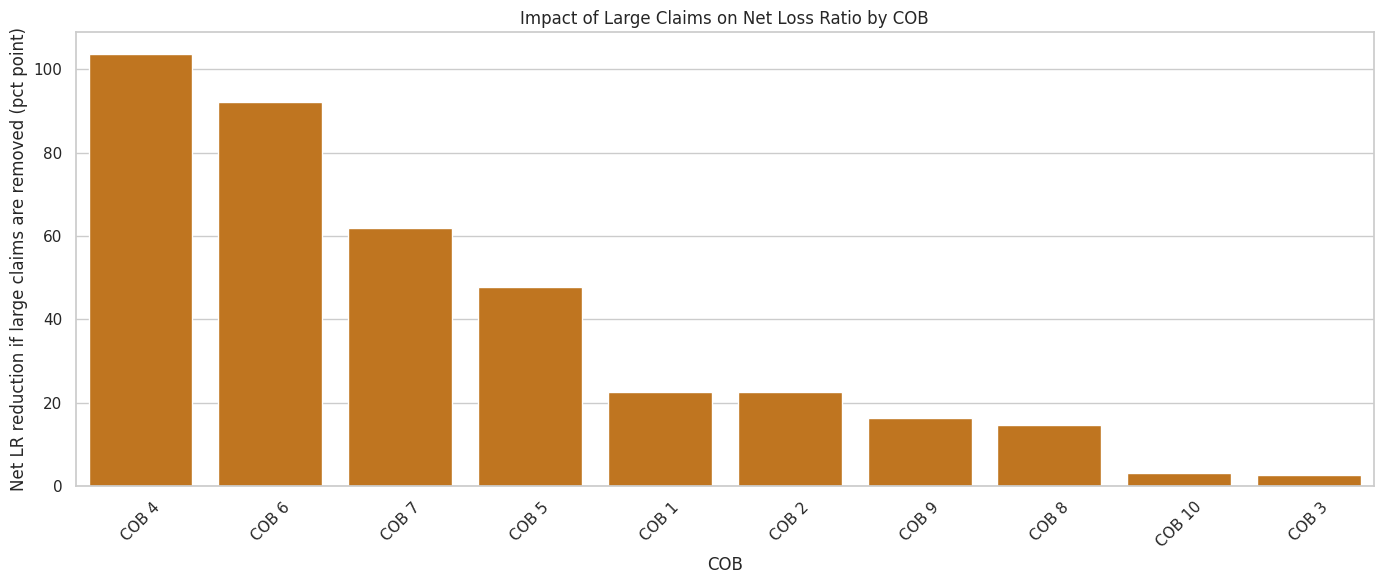

In [8]:
portfolio_compare = pd.concat([
    portfolio_metrics(df, 'All claims'),
    portfolio_metrics(df[~df['is_large_claim']].copy(), 'Without large claims')
], ignore_index=True)
display(portfolio_compare)

impact_by_focus_segment = []
for seg_value in focus_summary[FOCUS_SEGMENT_FOR_TREND].tolist():
    subset_all = df[df[FOCUS_SEGMENT_FOR_TREND] == seg_value].copy()
    subset_without_large = subset_all[~subset_all['is_large_claim']].copy()
    all_metrics = portfolio_metrics(subset_all, 'All claims').iloc[0]
    wo_metrics = portfolio_metrics(subset_without_large, 'Without large claims').iloc[0]
    impact_by_focus_segment.append({
        FOCUS_SEGMENT_FOR_TREND: seg_value,
        'net_lr_all_claims_pct': all_metrics['net_loss_ratio_pct'],
        'net_lr_without_large_claims_pct': wo_metrics['net_loss_ratio_pct'],
        'delta_pct_point': all_metrics['net_loss_ratio_pct'] - wo_metrics['net_loss_ratio_pct']
    })

impact_by_focus_segment = pd.DataFrame(impact_by_focus_segment).sort_values('delta_pct_point', ascending=False)
display(impact_by_focus_segment.head(TOP_N))

plt.figure(figsize=(14, 6))
sns.barplot(data=impact_by_focus_segment.head(TOP_N), x=FOCUS_SEGMENT_FOR_TREND, y='delta_pct_point', color='#d97706')
plt.title(f'Impact of Large Claims on Net Loss Ratio by {FOCUS_SEGMENT_FOR_TREND}')
plt.xlabel(FOCUS_SEGMENT_FOR_TREND)
plt.ylabel('Net LR reduction if large claims are removed (pct point)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


,uw_year,gwp,net_premium,gross_incurred_claim,net_incurred_claim,gross_loss_ratio_pct,net_loss_ratio_pct
0,2021,"1,557,352,471,342.61","1,358,688,779,647.98","984,489,956,173.63","934,424,814,229.26",63.22,68.77
1,2022,"471,373,718,715.47","296,871,160,261.39","112,610,571,387.11","97,320,336,460.67",23.89,32.78
2,2023,"481,993,283,992.36","308,561,317,659.29","141,781,037,467.73","118,007,939,079.13",29.42,38.24


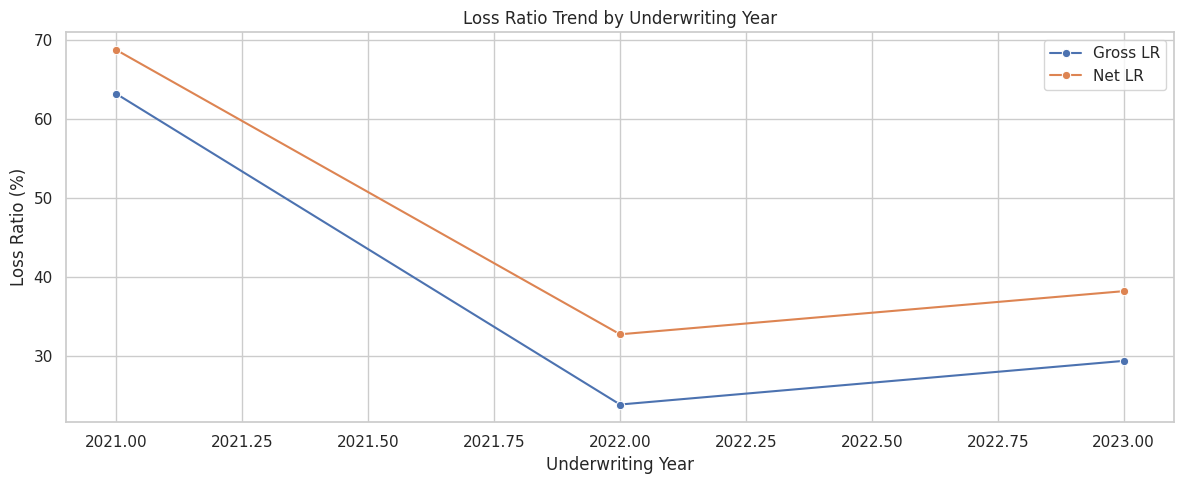

,uw_year,COB,gwp,net_premium,gross_incurred_claim,net_incurred_claim,net_loss_ratio_pct
0,2021,COB 10,"11,481,433,694.38","11,481,433,694.38","2,082,258,596.38","2,082,258,596.38",18.14
1,2021,COB 3,"14,298,051,207.62","3,937,006,957.49","585,609,740.44","286,812,024.68",7.29
2,2021,COB 4,"247,752,908,466.85","210,455,257,936.77","261,107,870,142.48","252,030,604,001.85",119.75
3,2021,COB 6,"411,280,103,562.72","405,911,997,232.40","369,315,991,107.86","368,884,899,496.30",90.88
4,2021,COB 7,"164,680,169,025.41","164,563,355,587.91","223,236,640,976.42","223,236,640,976.42",135.65
5,2021,COB 8,"246,527,590,827.02","246,492,726,277.02","37,549,499,255.27","37,549,499,255.27",15.23
6,2022,COB 10,"23,896,611,537.69","23,896,611,537.69","2,657,982,182.53","2,657,982,182.53",11.12
7,2022,COB 3,"17,957,986,213.65","5,068,694,321.06","454,198,929.06","420,524,090.87",8.30
8,2022,COB 4,"45,419,258,427.56","33,338,036,433.25","21,214,381,846.69","19,536,290,763.66",58.60
9,2022,COB 6,"3,934,416,756.72","3,832,365,945.65","218,401,437.88","218,401,437.88",5.70


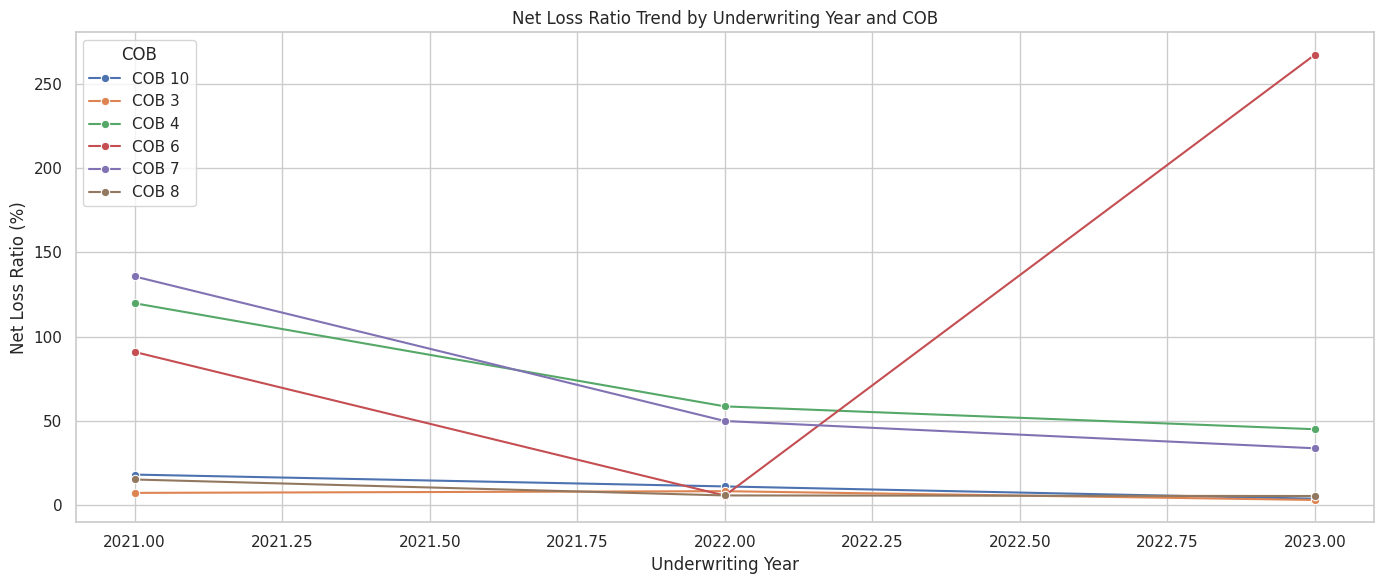

In [9]:
yearly = (
    df.groupby('uw_year', as_index=False)
    .agg(
        gwp=('GWP_IDR', 'sum'),
        net_premium=('net_premium', 'sum'),
        gross_incurred_claim=('gross_incurred_claim', 'sum'),
        net_incurred_claim=('net_incurred_claim', 'sum')
    )
)
yearly['gross_loss_ratio_pct'] = 100 * yearly['gross_incurred_claim'] / yearly['gwp']
yearly['net_loss_ratio_pct'] = 100 * yearly['net_incurred_claim'] / yearly['net_premium']
display(yearly)

plt.figure(figsize=(12, 5))
sns.lineplot(data=yearly, x='uw_year', y='gross_loss_ratio_pct', marker='o', label='Gross LR')
sns.lineplot(data=yearly, x='uw_year', y='net_loss_ratio_pct', marker='o', label='Net LR')
plt.title('Loss Ratio Trend by Underwriting Year')
plt.xlabel('Underwriting Year')
plt.ylabel('Loss Ratio (%)')
plt.tight_layout()
plt.show()

selected_segments = pd.concat([
    focus_summary.nsmallest(3, 'net_loss_ratio_pct')[[FOCUS_SEGMENT_FOR_TREND]],
    focus_summary.nlargest(3, 'net_loss_ratio_pct')[[FOCUS_SEGMENT_FOR_TREND]]
])[FOCUS_SEGMENT_FOR_TREND].drop_duplicates().tolist()

trend_by_segment = (
    df[df[FOCUS_SEGMENT_FOR_TREND].isin(selected_segments)]
    .groupby(['uw_year', FOCUS_SEGMENT_FOR_TREND], as_index=False)
    .agg(
        gwp=('GWP_IDR', 'sum'),
        net_premium=('net_premium', 'sum'),
        gross_incurred_claim=('gross_incurred_claim', 'sum'),
        net_incurred_claim=('net_incurred_claim', 'sum')
    )
)
trend_by_segment['net_loss_ratio_pct'] = 100 * trend_by_segment['net_incurred_claim'] / trend_by_segment['net_premium']
display(trend_by_segment)

plt.figure(figsize=(14, 6))
sns.lineplot(
    data=trend_by_segment,
    x='uw_year',
    y='net_loss_ratio_pct',
    hue=FOCUS_SEGMENT_FOR_TREND,
    marker='o'
)
plt.title(f'Net Loss Ratio Trend by Underwriting Year and {FOCUS_SEGMENT_FOR_TREND}')
plt.xlabel('Underwriting Year')
plt.ylabel('Net Loss Ratio (%)')
plt.tight_layout()
plt.show()


In [10]:
print('INTERPRETATION CHECKLIST')
print('- Loss Ratio > 100% => loss-making.')
print('- Net LR jauh lebih rendah dari Gross LR => reasuransi membantu memperbaiki portfolio.')
print('- Delta besar antara all claims vs without large claims => profitabilitas sangat sensitif terhadap large claim.')
print('- Trend naik antar underwriting year => underwriting profitability memburuk dan perlu investigasi lebih lanjut.')

for col, summary in segment_summaries.items():
    best = summary.nsmallest(1, 'net_loss_ratio_pct')
    worst = summary.nlargest(1, 'net_loss_ratio_pct')
    print(f'\nDimensi: {col}')
    print('Paling menguntungkan:')
    display(best[[col, 'gross_loss_ratio_pct', 'net_loss_ratio_pct', 'reinsurance_benefit_pct_point', 'profitability_flag']])
    print('Paling merugikan:')
    display(worst[[col, 'gross_loss_ratio_pct', 'net_loss_ratio_pct', 'reinsurance_benefit_pct_point', 'profitability_flag']])


INTERPRETATION CHECKLIST
- Loss Ratio > 100% => loss-making.
- Net LR jauh lebih rendah dari Gross LR => reasuransi membantu memperbaiki portfolio.
- Delta besar antara all claims vs without large claims => profitabilitas sangat sensitif terhadap large claim.
- Trend naik antar underwriting year => underwriting profitability memburuk dan perlu investigasi lebih lanjut.

Dimensi: COB
Paling menguntungkan:


,COB,gross_loss_ratio_pct,net_loss_ratio_pct,reinsurance_benefit_pct_point,profitability_flag
0,COB 3,2.23,6.03,-3.81,Profitable/acceptable


Paling merugikan:


,COB,gross_loss_ratio_pct,net_loss_ratio_pct,reinsurance_benefit_pct_point,profitability_flag
9,COB 4,91.27,106.55,-15.27,Loss-making



Dimensi: BRANCH_
Paling menguntungkan:


...

,CHANNEL_,gross_loss_ratio_pct,net_loss_ratio_pct,reinsurance_benefit_pct_point,profitability_flag
4,CHANNEL B,115.11,116.16,-1.05,Loss-making



Dimensi: PRODUCT_NAME
Paling menguntungkan:


,PRODUCT_NAME,gross_loss_ratio_pct,net_loss_ratio_pct,reinsurance_benefit_pct_point,profitability_flag
0,PRODUCT0106,0.00,0.00,0.00,Profitable/acceptable


Paling merugikan:


,PRODUCT_NAME,gross_loss_ratio_pct,net_loss_ratio_pct,reinsurance_benefit_pct_point,profitability_flag
55,PRODUCT1217,"21,083.37","21,083.37",0.00,Loss-making
